
INSTALL LIBRARIES



In [1]:
!pip install xgboost
!pip install tensorflow
!pip install shap
!pip install pytrends
!pip install streamlit
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 102.0 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import requests
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Dropout
)

from pytrends.request import TrendReq

import shap

UPLOAD DATASET


In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.csv.zip to train.csv.zip


EXTRACT ZIP FILE

In [4]:
with zipfile.ZipFile(
    'train.csv.zip',
    'r'
) as zip_ref:

    zip_ref.extractall()

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


LOAD DATASET

In [5]:
data = pd.read_csv(
    'train.csv',
    nrows=50000
)

print(data.shape)

data.head()

(50000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


GOOGLE TRENDS API

In [6]:
pytrend = TrendReq()

pytrend.build_payload(
    kw_list=['retail demand']
)

trends_data = pytrend.interest_over_time()

trends_data.reset_index(inplace=True)

trends_data.head()

,date,retail demand,isPartial
0,2021-05-16,4,False
1,2021-05-23,3,False
2,2021-05-30,3,False
3,2021-06-06,3,False
4,2021-06-13,3,False


WEATHER API INTEGRATION

In [7]:
import requests

API_KEY = "df7960eb884253db7b2795257b191f04"

city = "Chennai"

url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}"

response = requests.get(url)

weather_data = response.json()

print(weather_data)

{'coord': {'lon': 80.2785, 'lat': 13.0878}, 'weather': [{'id': 801, 'main': 'Clouds', 'description': 'few clouds', 'icon': '02d'}], 'base': 'stations', 'main': {'temp': 312.37, 'feels_like': 319.37, 'temp_min': 312.04, 'temp_max': 313.84, 'pressure': 1003, 'humidity': 52, 'sea_level': 1003, 'grnd_level': 1002}, 'visibility': 6000, 'wind': {'speed': 3.13, 'deg': 136, 'gust': 3.58}, 'clouds': {'all': 20}, 'dt': 1779352144, 'sys': {'type': 2, 'id': 2093935, 'country': 'IN', 'sunrise': 1779322344, 'sunset': 1779368327}, 'timezone': 19800, 'id': 1264527, 'name': 'Chennai', 'cod': 200}


EXTRACT WEATHER FEATURES

In [8]:
temperature = weather_data['main']['temp']

humidity = weather_data['main']['humidity']

print("Temperature :", temperature)

print("Humidity :", humidity)

Temperature : 312.37
Humidity : 52


ADD WEATHER DATA TO DATASET

In [9]:
data['temperature'] = temperature

data['humidity'] = humidity

data.head()

,date,store,item,sales,temperature,humidity
0,2013-01-01,1,1,13,312.37,52
1,2013-01-02,1,1,11,312.37,52
2,2013-01-03,1,1,14,312.37,52
3,2013-01-04,1,1,13,312.37,52
4,2013-01-05,1,1,10,312.37,52


FEATURE ENGINEERING

In [10]:
features = [
    'store',
    'item',
    'temperature',
    'humidity'
]

target = 'sales'

X = data[features]

y = data[target]

print(X.head())

   store  item  temperature  humidity
0      1     1       312.37        52
1      1     1       312.37        52
2      1     1       312.37        52
3      1     1       312.37        52
4      1     1       312.37        52


ENCODE CATEGORICAL DATA

In [11]:
X = pd.get_dummies(X)

X.head()

,store,item,temperature,humidity
0,1,1,312.37,52
1,1,1,312.37,52
2,1,1,312.37,52
3,1,1,312.37,52
4,1,1,312.37,52


NORMALIZATION

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


TRAIN TEST SPLIT

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(40000, 4)
(10000, 4)


RANDOM FOREST MODEL

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

print("Random Forest Completed")

Random Forest Completed


XGBOOST MODEL

In [15]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

print("XGBoost Completed")

XGBoost Completed


RESHAPE DATA FOR LSTM

In [16]:
X_train_lstm = np.reshape(
    X_train,
    (
        X_train.shape[0],
        X_train.shape[1],
        1
    )
)

X_test_lstm = np.reshape(
    X_test,
    (
        X_test.shape[0],
        X_test.shape[1],
        1
    )
)

print(X_train_lstm.shape)

(40000, 4, 1)


BUILD LSTM MODEL

In [17]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Dropout
)

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            1
        )
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    LSTM(32)
)

lstm_model.add(
    Dense(1)
)

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

TRAIN LSTM MODEL

In [18]:
history = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 773.0411 - val_loss: 495.8663
Epoch 2/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 471.9089 - val_loss: 476.9761
Epoch 3/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 468.7452 - val_loss: 476.8865
Epoch 4/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 339.0077 - val_loss: 305.2738
Epoch 5/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 302.4924 - val_loss: 307.1458


LSTM PREDICTIONS

In [19]:
lstm_predictions = lstm_model.predict(
    X_test_lstm
)

print("LSTM Completed")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM Completed


HYBRID FORECASTING

In [20]:
final_predictions = (
    rf_predictions +
    xgb_predictions +
    lstm_predictions.flatten()
) / 3

print(final_predictions[:10])

[57.39781374 17.83022457 20.65391519 16.63384368 47.36592572 42.15458297
 17.83022457 43.6455506  25.48183933 38.2439668 ]


MODEL EVALUATION

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    final_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

r2 = r2_score(
    y_test,
    final_predictions
)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 9.714610954604614
RMSE : 12.89000493339238
R2 Score : 0.6432657197300047


FEEDBACK LOOP

In [22]:
# =========================
# FEEDBACK LOOP
# =========================

feedback_df = pd.DataFrame({
    'Actual_Sales': y_test.values,
    'Predicted_Sales': final_predictions
})

feedback_df['Error'] = (
    feedback_df['Actual_Sales']
    - feedback_df['Predicted_Sales']
)

feedback_df['Absolute_Error'] = np.abs(
    feedback_df['Error']
)

print(feedback_df.head())

# Average Forecast Error
mae_feedback = feedback_df['Absolute_Error'].mean()

print(f"Average Forecast Error: {mae_feedback:.2f}")

   Actual_Sales  Predicted_Sales      Error  Absolute_Error
0            39        57.397814 -18.397814       18.397814
1            18        17.830225   0.169775        0.169775
2            25        20.653915   4.346085        4.346085
3             9        16.633844  -7.633844        7.633844
4            42        47.365926  -5.365926        5.365926
Average Forecast Error: 9.71


In [33]:
# =========================
# DRIFT DETECTION
# =========================

drift_threshold = 20

if mae_feedback > drift_threshold:
    print("WARNING: MODEL DRIFT DETECTED")
else:
    print("Model performance stable")

Model performance stable


SHAP EXPLAINABILITY

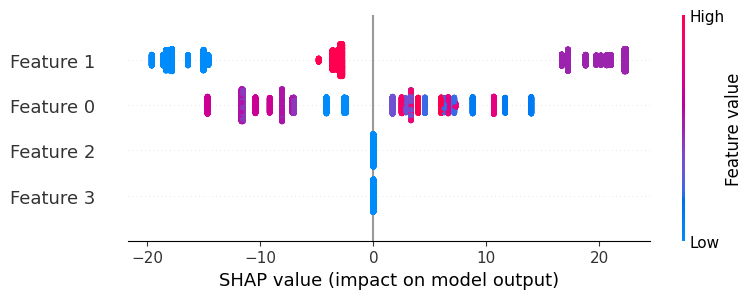

In [35]:
import shap

explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(
    shap_values,
    X_test
)

INVENTORY OPTIMIZATION

In [24]:
lead_time = 7

service_factor = 1.65

avg_demand = np.mean(
    final_predictions
)

std_demand = np.std(
    final_predictions
)

safety_stock = (
    service_factor *
    std_demand *
    np.sqrt(lead_time)
)

reorder_point = (
    avg_demand *
    lead_time
) + safety_stock

print(
    "Safety Stock :",
    safety_stock
)

print(
    "Reorder Point :",
    reorder_point
)

Safety Stock : 66.81159878351366
Reorder Point : 338.5358311764879


DECISION ENGINE

In [38]:
import pandas as pd
import numpy as np

# =========================
# DECISION ENGINE
# =========================

# Create a DataFrame to hold the relevant data for decision making
# Using y_test as a proxy for 'Current_Stock' for demonstration purposes
# as actual current stock data is not present in the notebook.
decision_engine_df = pd.DataFrame({
    'Current_Stock': y_test.values, # Placeholder: In a real scenario, this would be actual inventory data.
    'Predicted_Demand': final_predictions
})

# Add the calculated global reorder_point and safety_stock to each row
decision_engine_df['Reorder_Point'] = reorder_point
decision_engine_df['Safety_Stock'] = safety_stock

def inventory_decision(row):
    if row['Current_Stock'] < row['Reorder_Point']:
        return "URGENT REORDER"
    elif row['Current_Stock'] < row['Safety_Stock']:
        return "LOW STOCK WARNING"
    elif row['Predicted_Demand'] > row['Current_Stock']:
        return "HIGH DEMAND RISK"
    else:
        return "STOCK HEALTHY"

decision_engine_df['Decision'] = decision_engine_df.apply(
    inventory_decision,
    axis=1
)

# Display the head of the relevant columns
print(decision_engine_df[
    ['Current_Stock',
     'Predicted_Demand',
     'Reorder_Point',
     'Safety_Stock',
     'Decision']
].head())

   Current_Stock  Predicted_Demand  Reorder_Point  Safety_Stock  \
0             39         57.397814     338.535831     66.811599   
1             18         17.830225     338.535831     66.811599   
2             25         20.653915     338.535831     66.811599   
3              9         16.633844     338.535831     66.811599   
4             42         47.365926     338.535831     66.811599   

         Decision  
0  URGENT REORDER  
1  URGENT REORDER  
2  URGENT REORDER  
3  URGENT REORDER  
4  URGENT REORDER  


In [40]:
# =========================
# ALERT SYSTEM
# =========================

for idx, row in decision_engine_df.iterrows():

    if row['Decision'] == "URGENT REORDER":

        print(f"""
        ALERT:
        Product Index: {idx}

        Current Stock:
        {row['Current_Stock']}

        Predicted Demand:
        {row['Predicted_Demand']}

        Recommended Action:
        Reorder inventory immediately.
        """)


Streaming output truncated to the last 5000 lines.
        47

        Predicted Demand:
        42.154582970151466

        Recommended Action:
        Reorder inventory immediately.
        

        ALERT:
        Product Index: 9616

        Current Stock:
        64

        Predicted Demand:
        57.39781374467206

        Recommended Action:
        Reorder inventory immediately.
        

        ALERT:
        Product Index: 9617

        Current Stock:
        51

        Predicted Demand:
        45.77949539251193

        Recommended Action:
        Reorder inventory immediately.
        

        ALERT:
        Product Index: 9618

        Current Stock:
        54

        Predicted Demand:
        47.36592572441507

        Recommended Action:
        Reorder inventory immediately.
        

        ALERT:
        Product Index: 9619

        Current Stock:
        23

        Predicted Demand:
        24.547942926572475

        Recommended Action:
        Reorder in

In [42]:
# =========================
# BUSINESS ACTION LAYER
# =========================

decision_engine_df['Recommended_Order_Qty'] = (
    decision_engine_df['Predicted_Demand']
    + decision_engine_df['Safety_Stock']
    - decision_engine_df['Current_Stock']
)

decision_engine_df['Recommended_Order_Qty'] = (
    decision_engine_df['Recommended_Order_Qty']
    .clip(lower=0)
)

print(decision_engine_df[
    ['Current_Stock',
     'Predicted_Demand',
     'Recommended_Order_Qty']
].head())

   Current_Stock  Predicted_Demand  Recommended_Order_Qty
0             39         57.397814              85.209413
1             18         17.830225              66.641823
2             25         20.653915              62.465514
3              9         16.633844              74.445442
4             42         47.365926              72.177525


VISUALIZATION

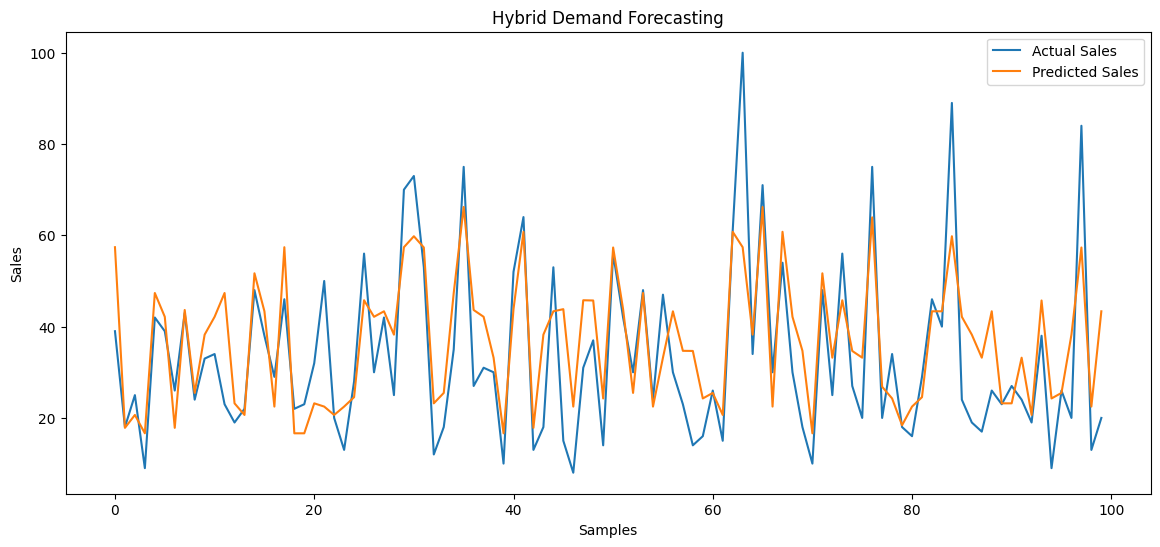

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:100],
    label='Actual Sales'
)

plt.plot(
    final_predictions[:100],
    label='Predicted Sales'
)

plt.title(
    'Hybrid Demand Forecasting'
)

plt.xlabel('Samples')

plt.ylabel('Sales')

plt.legend()

plt.show()

**DASHBOARD**

INSTALL PLOTLY

In [27]:
!pip install plotly

DASHBOARD CELL

In [28]:
import plotly.graph_objects as go
import plotly.express as px

# =====================================
# SALES FORECAST GRAPH
# =====================================

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=y_test.values[:100],
        mode='lines',
        name='Actual Sales'
    )
)

fig.add_trace(
    go.Scatter(
        y=final_predictions[:100],
        mode='lines',
        name='Predicted Sales'
    )
)

fig.update_layout(
    title='Hybrid Demand Forecasting',
    xaxis_title='Samples',
    yaxis_title='Sales',
    template='plotly_dark'
)

fig.show()

INVENTORY DASHBOARD

In [29]:
inventory_data = {
    'Metric': [
        'Safety Stock',
        'Reorder Point'
    ],
    'Value': [
        safety_stock,
        reorder_point
    ]
}

inventory_df = pd.DataFrame(
    inventory_data
)

fig2 = px.bar(
    inventory_df,
    x='Metric',
    y='Value',
    title='Inventory Optimization'
)

fig2.show()

MODEL PERFORMANCE DASHBOARD

In [30]:
metrics = pd.DataFrame({
    'Metric': [
        'MAE',
        'RMSE',
        'R2 Score'
    ],
    'Value': [
        mae,
        rmse,
        r2
    ]
})

fig3 = px.bar(
    metrics,
    x='Metric',
    y='Value',
    title='Model Performance'
)

fig3.show()

FEATURE IMPORTANCE DASHBOARD

In [31]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

fig4 = px.bar(
    importance_df,
    x='Feature',
    y='Importance',
    title='Feature Importance'
)

fig4.show()

In [43]:
# =====================================
# DASHBOARD KPIs
# =====================================

total_metrics = len(metrics)

top_feature = importance_df.iloc[0]['Feature']

top_importance = importance_df.iloc[0]['Importance']

print("===== DASHBOARD KPIs =====")

print(f"Total Evaluation Metrics: {total_metrics}")

print(f"Most Important Feature: {top_feature}")

print(f"Importance Score: {top_importance:.4f}")

print(f"Safety Stock: {safety_stock}")

print(f"Reorder Point: {reorder_point}")

===== DASHBOARD KPIs =====
Total Evaluation Metrics: 3
Most Important Feature: item
Importance Score: 0.7827
Safety Stock: 66.81159878351366
Reorder Point: 338.5358311764879


DECISION ENGINE OUTPUT

In [32]:
if current_inventory < reorder_point:

    print("ALERT : REORDER INVENTORY")

else:

    print("Inventory Level Safe")

Inventory Level Safe


In [44]:
# =====================================
# CONTINUOUS LEARNING STORAGE
# =====================================

model_log = pd.DataFrame({
    'MAE': [mae],
    'RMSE': [rmse],
    'R2_Score': [r2],
    'Timestamp': [pd.Timestamp.now()]
})

model_log.to_csv(
    'model_performance_log.csv',
    index=False
)

print("Model performance logged successfully")

print(model_log)

Model performance logged successfully
        MAE       RMSE  R2_Score                  Timestamp
0  9.714611  12.890005  0.643266 2026-05-21 08:52:54.249005


In [48]:
# =========================================================
# STREAMLIT + NGROK DASHBOARD (FULL WORKING VERSION)
# =========================================================

# INSTALL LIBRARIES
!pip install streamlit pyngrok plotly -q

# =========================================================
# PREPARE VARIABLES FOR STREAMLIT
# =========================================================

import pandas as pd
import numpy as np

# MODEL METRICS
mae_value = float(mae)
rmse_value = float(rmse)
r2_value = float(r2)

# INVENTORY VALUES
safety_stock_value = float(safety_stock)
reorder_point_value = float(reorder_point)

# SAMPLE INVENTORY
current_inventory = 120

# SALES DATA
actual_sales = y_test.values[:30].tolist()

predicted_sales = final_predictions[:30].tolist()

# FEATURE IMPORTANCE
importance_features = importance_df['Feature'].tolist()

importance_values = (
    importance_df['Importance']
    .tolist()
)

# =========================================================
# CREATE STREAMLIT APP
# =========================================================

app_code = f"""

import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="AI Supply Chain Dashboard",
    layout="wide"
)

st.title("AI-Powered Supply Chain Intelligence System")

# =========================================================
# KPI SECTION
# =========================================================

st.subheader("Model Performance KPIs")

col1, col2, col3 = st.columns(3)

col1.metric("MAE", round({mae_value}, 2))
col2.metric("RMSE", round({rmse_value}, 2))
col3.metric("R2 Score", round({r2_value}, 2))

# =========================================================
# SALES FORECAST GRAPH
# =========================================================

st.subheader("Hybrid Demand Forecasting")

actual_sales = {actual_sales}

predicted_sales = {predicted_sales}

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=actual_sales,
        mode='lines',
        name='Actual Sales'
    )
)

fig.add_trace(
    go.Scatter(
        y=predicted_sales,
        mode='lines',
        name='Predicted Sales'
    )
)

fig.update_layout(
    title='Sales Forecast',
    xaxis_title='Samples',
    yaxis_title='Sales',
    template='plotly_dark'
)

st.plotly_chart(fig, use_container_width=True)

# =========================================================
# INVENTORY DASHBOARD
# =========================================================

st.subheader("Inventory Optimization")

inventory_dashboard = pd.DataFrame({{
    'Metric': [
        'Safety Stock',
        'Reorder Point'
    ],
    'Value': [
        {safety_stock_value},
        {reorder_point_value}
    ]
}})

fig2 = px.bar(
    inventory_dashboard,
    x='Metric',
    y='Value',
    title='Inventory Optimization'
)

st.plotly_chart(fig2, use_container_width=True)

# =========================================================
# MODEL PERFORMANCE DASHBOARD
# =========================================================

st.subheader("Model Metrics")

metrics_df = pd.DataFrame({{
    'Metric': [
        'MAE',
        'RMSE',
        'R2 Score'
    ],
    'Value': [
        {mae_value},
        {rmse_value},
        {r2_value}
    ]
}})

fig3 = px.bar(
    metrics_df,
    x='Metric',
    y='Value',
    title='Model Performance'
)

st.plotly_chart(fig3, use_container_width=True)

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

st.subheader("Feature Importance")

feature_df = pd.DataFrame({{
    'Feature': {importance_features},
    'Importance': {importance_values}
}})

fig4 = px.bar(
    feature_df,
    x='Feature',
    y='Importance',
    title='Feature Importance'
)

st.plotly_chart(fig4, use_container_width=True)

# =========================================================
# DECISION ENGINE
# =========================================================

st.subheader("Decision Engine")

current_inventory = {current_inventory}

reorder_point = {reorder_point_value}

safety_stock = {safety_stock_value}

if current_inventory < reorder_point:

    st.error("URGENT REORDER REQUIRED")

elif current_inventory < safety_stock:

    st.warning("LOW STOCK WARNING")

else:

    st.success("Inventory Level Safe")

# =========================================================
# CONTINUOUS LEARNING STORAGE
# =========================================================

st.subheader("Continuous Learning Log")

model_log = pd.DataFrame({{
    'MAE': [{mae_value}],
    'RMSE': [{rmse_value}],
    'R2_Score': [{r2_value}]
}})

st.dataframe(model_log)

"""

# WRITE APP FILE
with open("app.py", "w") as f:
    f.write(app_code)

# =========================================================
# NGROK SETUP
# =========================================================

from pyngrok import ngrok
import time

# ADD YOUR NGROK TOKEN
ngrok.set_auth_token("2ucHGXgsBCOLijgybTQQVhH61NJ_5WqxWUZzNxVjNcFGqN1EN")

# =========================================================
# RUN STREAMLIT
# =========================================================

!streamlit run app.py --server.headless true >/dev/null 2>&1 &

# WAIT FOR SERVER
time.sleep(5)

# =========================================================
# CREATE PUBLIC URL
# =========================================================

public_url = ngrok.connect(8501)

print("Dashboard URL:")
print(public_url)

Dashboard URL:
NgrokTunnel: "https://2b77-136-111-255-188.ngrok-free.app" -> "http://localhost:8501"
